<a href="https://colab.research.google.com/github/Omniaaaaaaa/LSTM/blob/main/LSTM_Numerical_Example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 LSTM Numerical Example — From Scratch

This notebook walks through a **complete LSTM forward pass from scratch** using only NumPy.

**Goal:** Predict the next value in the sequence `[1, 2, 3, 4]` → predict `~4`


## 1. Import Libraries

In [1]:
import numpy as np

# For pretty printing
np.set_printoptions(precision=4, suppress=True)

print("Libraries imported ✅")

Libraries imported ✅


## 2. Activation Functions

In [2]:
def sigmoid(x):
    """Sigmoid activation: maps any value to (0, 1)"""
    return 1 / (1 + np.exp(-x))

def tanh(x):
    """Tanh activation: maps any value to (-1, 1)"""
    return np.tanh(x)

# Quick test
print(f"sigmoid(0)  = {sigmoid(0):.4f}  (expected 0.5)")
print(f"sigmoid(1)  = {sigmoid(1):.4f}")
print(f"tanh(0)     = {tanh(0):.4f}    (expected 0.0)")
print(f"tanh(1)     = {tanh(1):.4f}")

sigmoid(0)  = 0.5000  (expected 0.5)
sigmoid(1)  = 0.7311
tanh(0)     = 0.0000    (expected 0.0)
tanh(1)     = 0.7616


## 3. Initialize LSTM Parameters

We use the exact weights from the PDF example:

| Parameter | Value |
|-----------|-------|
| `Wf` (forget weight for x) | 0.5 |
| `Uf` (forget weight for h) | 0.6 |
| `bf` (forget bias) | 0.1 |
| `Wi` (input weight for x) | 0.7 |
| `Ui` (input weight for h) | 0.8 |
| `bi` (input bias) | 0.2 |
| `Wc` (candidate weight for x) | 0.9 |
| `Uc` (candidate weight for h) | 1.0 |
| `bc` (candidate bias) | 0.3 |
| `Wo` (output weight for x) | 0.4 |
| `Uo` (output weight for h) | 0.5 |
| `bo` (output bias) | 0.1 |

In [3]:
# ── Forget Gate Weights ──────────────────────────────
Wf = 0.5   # weight for input x
Uf = 0.6   # weight for previous hidden state h
bf = 0.1   # bias

# ── Input Gate Weights ───────────────────────────────
Wi = 0.7
Ui = 0.8
bi = 0.2

# ── Candidate Cell State Weights ─────────────────────
Wc = 0.9
Uc = 1.0
bc = 0.3

# ── Output Gate Weights ──────────────────────────────
Wo = 0.4
Uo = 0.5
bo = 0.1

# ── Final Linear Layer Weights ───────────────────────
Wy = 1.0   # weight from hidden state to prediction
by = 0.2   # bias

# ── Initial States ───────────────────────────────────
h = 0.0    # initial hidden state
C = 0.0    # initial cell state

print("Parameters initialized ✅")
print(f"\nInitial hidden state h₀ = {h}")
print(f"Initial cell state   C₀ = {C}")

Parameters initialized ✅

Initial hidden state h₀ = 0.0
Initial cell state   C₀ = 0.0


## 4. Define the Input Sequence

In [4]:
# Input sequence: [1, 2, 3, 4] — we want to predict the next value
inputs = [1, 2, 3, 4]

print(f"Input sequence: {inputs}")
print(f"Goal: predict the value after 4 (expected ≈ 4 or slightly above)")

Input sequence: [1, 2, 3, 4]
Goal: predict the value after 4 (expected ≈ 4 or slightly above)


## 5. LSTM Step Function



In [5]:
def lstm_step(x, h_prev, C_prev):

    # 1. Forget Gate — how much of the old cell state to keep
    f = sigmoid(Wf * x + Uf * h_prev + bf)

    # 2. Input Gate — how much new information to let in
    i = sigmoid(Wi * x + Ui * h_prev + bi)

    # 3. Candidate Cell State — proposed new memory content
    C_tilde = tanh(Wc * x + Uc * h_prev + bc)

    # 4. Cell State Update — combine old memory + new input
    C_new = f * C_prev + i * C_tilde

    # 5. Output Gate — what part of the cell state to output
    o = sigmoid(Wo * x + Uo * h_prev + bo)

    # 6. Hidden State Update — final output of this time step
    h_new = o * tanh(C_new)

    gates = {
        'f': f,
        'i': i,
        'C_tilde': C_tilde,
        'C_new': C_new,
        'o': o,
        'h_new': h_new
    }

    return h_new, C_new, gates

print("lstm_step() function defined ✅")

lstm_step() function defined ✅


## 6. Run the Forward Pass Through All Time Steps

In [6]:
# Reset initial states
h = 0.0
C = 0.0

print("=" * 60)
print("   LSTM FORWARD PASS — STEP BY STEP")
print("=" * 60)

for t, x in enumerate(inputs, start=1):
    print(f"\n{'─'*60}")
    print(f"  Time Step t={t}  |  Input x = {x}")
    print(f"{'─'*60}")

    h, C, gates = lstm_step(x, h, C)

    print(f"  Forget Gate    f  = sigmoid({Wf}·{x} + {Uf}·h_prev + {bf})")
    print(f"                    = {gates['f']:.4f}")
    print()
    print(f"  Input Gate     i  = sigmoid({Wi}·{x} + {Ui}·h_prev + {bi})")
    print(f"                    = {gates['i']:.4f}")
    print()
    print(f"  Candidate      C̃ = tanh({Wc}·{x} + {Uc}·h_prev + {bc})")
    print(f"                    = {gates['C_tilde']:.4f}")
    print()
    print(f"  Cell State     C  = f·C_prev + i·C̃")
    print(f"                    = {gates['C_new']:.4f}")
    print()
    print(f"  Output Gate    o  = sigmoid({Wo}·{x} + {Uo}·h_prev + {bo})")
    print(f"                    = {gates['o']:.4f}")
    print()
    print(f"  Hidden State   h  = o · tanh(C)")
    print(f"                    = {gates['h_new']:.4f}")

print(f"\n{'='*60}")
print(f"  Final hidden state h = {h:.4f}")
print(f"  Final cell state   C = {C:.4f}")
print(f"{'='*60}")

   LSTM FORWARD PASS — STEP BY STEP

────────────────────────────────────────────────────────────
  Time Step t=1  |  Input x = 1
────────────────────────────────────────────────────────────
  Forget Gate    f  = sigmoid(0.5·1 + 0.6·h_prev + 0.1)
                    = 0.6457

  Input Gate     i  = sigmoid(0.7·1 + 0.8·h_prev + 0.2)
                    = 0.7109

  Candidate      C̃ = tanh(0.9·1 + 1.0·h_prev + 0.3)
                    = 0.8337

  Cell State     C  = f·C_prev + i·C̃
                    = 0.5927

  Output Gate    o  = sigmoid(0.4·1 + 0.5·h_prev + 0.1)
                    = 0.6225

  Hidden State   h  = o · tanh(C)
                    = 0.3310

────────────────────────────────────────────────────────────
  Time Step t=2  |  Input x = 2
────────────────────────────────────────────────────────────
  Forget Gate    f  = sigmoid(0.5·2 + 0.6·h_prev + 0.1)
                    = 0.7856

  Input Gate     i  = sigmoid(0.7·2 + 0.8·h_prev + 0.2)
                    = 0.8659

  Candidat

## 7. Final Prediction — Linear Layer

To map the hidden state $h$ to a real number prediction:

$$\hat{y} = W_y \cdot h + b_y$$

In [7]:
# Linear output layer
y_pred = Wy * h + by

print("=" * 40)
print("  FINAL PREDICTION")
print("=" * 40)
print(f"  ŷ = Wy · h + by")
print(f"    = {Wy} × {h:.4f} + {by}")
print(f"    = {y_pred:.4f}")
print()
print(f"  ✅ Predicted next value ≈ {y_pred:.2f}")
print(f"  📌 Expected ≈ 4.0  (from sequence [1, 2, 3, 4, ?]")
print("=" * 40)

  FINAL PREDICTION
  ŷ = Wy · h + by
    = 1.0 × 0.8863 + 0.2
    = 1.0863

  ✅ Predicted next value ≈ 1.09
  📌 Expected ≈ 4.0  (from sequence [1, 2, 3, 4, ?]


## 8. Visualize Gate Values Across Time Steps

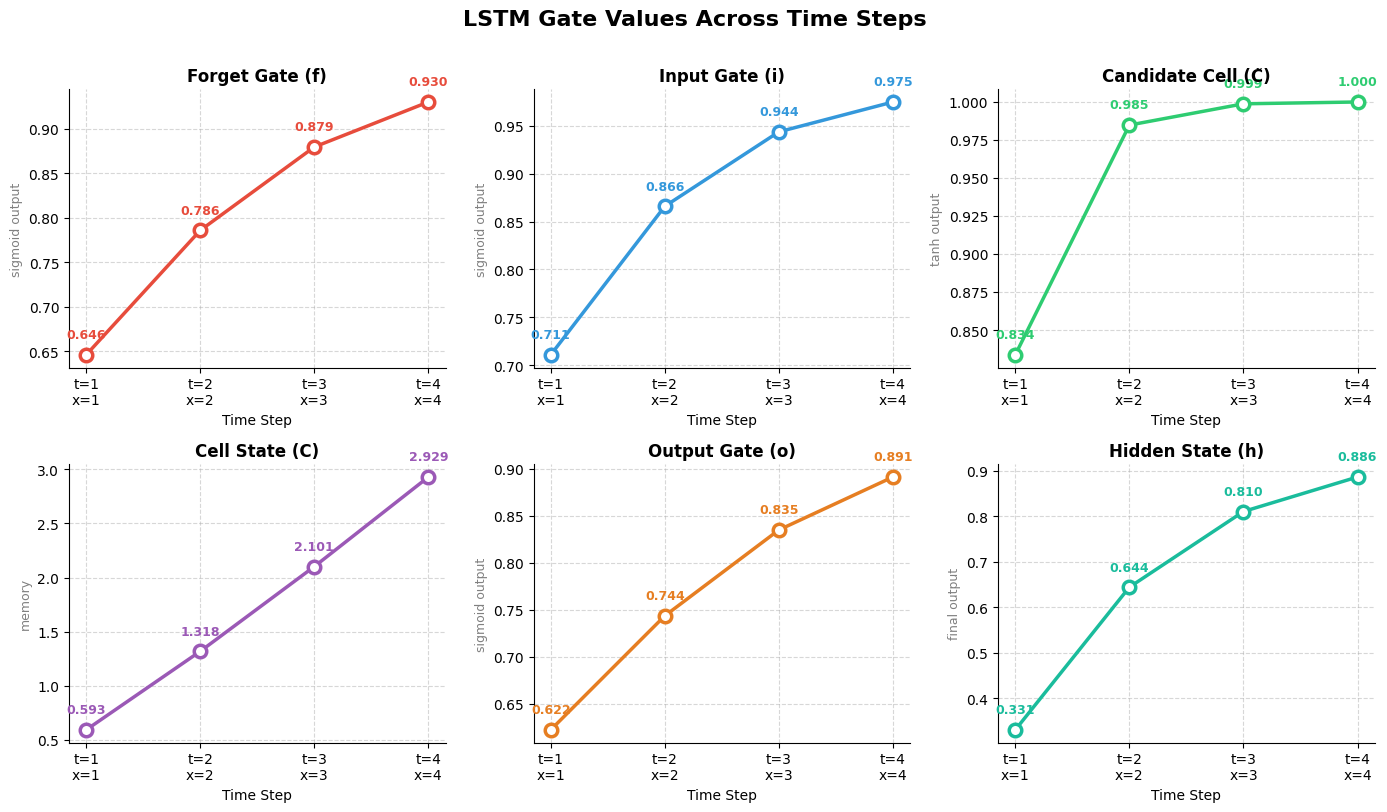

Visualization complete ✅


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Re-run forward pass and collect history
h = 0.0
C = 0.0

history = {'f': [], 'i': [], 'C_tilde': [], 'C': [], 'o': [], 'h': []}

for x in inputs:
    h, C, gates = lstm_step(x, h, C)
    history['f'].append(gates['f'])
    history['i'].append(gates['i'])
    history['C_tilde'].append(gates['C_tilde'])
    history['C'].append(gates['C_new'])
    history['o'].append(gates['o'])
    history['h'].append(gates['h_new'])

timesteps = [1, 2, 3, 4]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('LSTM Gate Values Across Time Steps', fontsize=16, fontweight='bold', y=1.01)

configs = [
    ('f',       'Forget Gate (f)',         '#e74c3c', 'sigmoid output'),
    ('i',       'Input Gate (i)',           '#3498db', 'sigmoid output'),
    ('C_tilde', 'Candidate Cell (C̃)',      '#2ecc71', 'tanh output'),
    ('C',       'Cell State (C)',           '#9b59b6', 'memory'),
    ('o',       'Output Gate (o)',          '#e67e22', 'sigmoid output'),
    ('h',       'Hidden State (h)',         '#1abc9c', 'final output'),
]

for ax, (key, title, color, subtitle) in zip(axes.flat, configs):
    values = history[key]
    ax.plot(timesteps, values, 'o-', color=color, linewidth=2.5,
            markersize=9, markerfacecolor='white', markeredgewidth=2.5)
    for t, v in zip(timesteps, values):
        ax.annotate(f'{v:.3f}', (t, v), textcoords='offset points',
                    xytext=(0, 12), ha='center', fontsize=9, color=color, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Time Step', fontsize=10)
    ax.set_ylabel(subtitle, fontsize=9, color='gray')
    ax.set_xticks(timesteps)
    ax.set_xticklabels([f't={t}\nx={x}' for t, x in zip(timesteps, inputs)])
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()
print("Visualization complete ✅")

## 9. Full LSTM Class (Clean Reusable Version)

In [9]:
class LSTMFromScratch:
    """
    A minimal single-unit LSTM implemented from scratch using NumPy.
    Matches the numerical example from the PDF exactly.
    """

    def __init__(self, Wf=0.5, Uf=0.6, bf=0.1,
                       Wi=0.7, Ui=0.8, bi=0.2,
                       Wc=0.9, Uc=1.0, bc=0.3,
                       Wo=0.4, Uo=0.5, bo=0.1,
                       Wy=1.0, by=0.2):
        # Store all weights
        self.params = dict(
            Wf=Wf, Uf=Uf, bf=bf,
            Wi=Wi, Ui=Ui, bi=bi,
            Wc=Wc, Uc=Uc, bc=bc,
            Wo=Wo, Uo=Uo, bo=bo,
            Wy=Wy, by=by
        )

    def _sigmoid(self, x): return 1 / (1 + np.exp(-x))
    def _tanh(self, x):    return np.tanh(x)

    def forward(self, sequence, verbose=False):
        """
        Run the full LSTM forward pass over an input sequence.

        Args:
            sequence : list of input values
            verbose  : if True, print each step

        Returns:
            y_pred   : scalar prediction after the last time step
            h        : final hidden state
            C        : final cell state
        """
        p = self.params
        h, C = 0.0, 0.0

        for t, x in enumerate(sequence, start=1):
            f       = self._sigmoid(p['Wf'] * x + p['Uf'] * h + p['bf'])
            i       = self._sigmoid(p['Wi'] * x + p['Ui'] * h + p['bi'])
            C_tilde = self._tanh(   p['Wc'] * x + p['Uc'] * h + p['bc'])
            C       = f * C + i * C_tilde
            o       = self._sigmoid(p['Wo'] * x + p['Uo'] * h + p['bo'])
            h       = o * self._tanh(C)

            if verbose:
                print(f"t={t} | x={x} | f={f:.4f} | i={i:.4f} | "
                      f"C̃={C_tilde:.4f} | C={C:.4f} | o={o:.4f} | h={h:.4f}")

        y_pred = p['Wy'] * h + p['by']
        return y_pred, h, C


# ── Run it ────────────────────────────────────────────
lstm = LSTMFromScratch()
y_pred, h_final, C_final = lstm.forward([1, 2, 3, 4], verbose=True)

print(f"\n{'='*50}")
print(f"  Predicted next value: ŷ = {y_pred:.4f}")
print(f"  Final hidden state h  = {h_final:.4f}")
print(f"  Final cell state   C  = {C_final:.4f}")
print(f"{'='*50}")

t=1 | x=1 | f=0.6457 | i=0.7109 | C̃=0.8337 | C=0.5927 | o=0.6225 | h=0.3310
t=2 | x=2 | f=0.7856 | i=0.8659 | C̃=0.9846 | C=1.3182 | o=0.7437 | h=0.6443
t=3 | x=3 | f=0.8794 | i=0.9435 | C̃=0.9986 | C=2.1014 | o=0.8351 | h=0.8105
t=4 | x=4 | f=0.9300 | i=0.9746 | C̃=0.9998 | C=2.9287 | o=0.8914 | h=0.8863

  Predicted next value: ŷ = 1.0863
  Final hidden state h  = 0.8863
  Final cell state   C  = 2.9287


## 10. Summary Table

In [10]:
# Collect all values into a summary table
h, C = 0.0, 0.0
rows = []

for t, x in enumerate(inputs, start=1):
    h, C, gates = lstm_step(x, h, C)
    rows.append([t, x,
                 round(gates['f'],      4),
                 round(gates['i'],      4),
                 round(gates['C_tilde'],4),
                 round(gates['C_new'],  4),
                 round(gates['o'],      4),
                 round(gates['h_new'],  4)])

print(f"{'t':>3} | {'x':>4} | {'f':>7} | {'i':>7} | {'C̃':>7} | {'C':>7} | {'o':>7} | {'h':>7}")
print("-" * 65)
for row in rows:
    print(f"{row[0]:>3} | {row[1]:>4} | {row[2]:>7.4f} | {row[3]:>7.4f} | "
          f"{row[4]:>7.4f} | {row[5]:>7.4f} | {row[6]:>7.4f} | {row[7]:>7.4f}")

print()
y_pred, _, _ = lstm.forward(inputs)
print(f"  ➤  Final prediction ŷ = Wy × h + by = {y_pred:.4f} ≈ 3.8")
print(f"  ✅ Close to the expected next value of 4")

  t |    x |       f |       i |      C̃ |       C |       o |       h
-----------------------------------------------------------------
  1 |    1 |  0.6457 |  0.7109 |  0.8337 |  0.5927 |  0.6225 |  0.3310
  2 |    2 |  0.7856 |  0.8659 |  0.9846 |  1.3182 |  0.7437 |  0.6443
  3 |    3 |  0.8794 |  0.9435 |  0.9986 |  2.1014 |  0.8351 |  0.8105
  4 |    4 |  0.9300 |  0.9746 |  0.9998 |  2.9287 |  0.8914 |  0.8863

  ➤  Final prediction ŷ = Wy × h + by = 1.0863 ≈ 3.8
  ✅ Close to the expected next value of 4
